# Практическое задание №4

Используйте данные из файла **StudentPerformanceFactors.csv** с информацией о студентах.

[Источник](https://www.kaggle.com/datasets/lainguyn123/student-performance-factors/code)

В нём содержаться следующие переменные:


| Название переменной | Описание переменной
|:-------------------:|:------------------:|
| Hours_Studied | Number of hours spent studying per week |
| Attendance | Percentage of classes attended |
| Parental_Involvement | Level of parental involvement in the student's education (Low, Medium, High)|
| Access_to_Resources | Availability of educational resources (Low, Medium, High)|
| Extracurricular_Activities | Participation in extracurricular activities (Yes, No).
| Sleep_Hours | Average number of hours of sleep per night.
| Previous_Scores |	Scores from previous exams.
| Motivation_Level |	Student's level of motivation (Low, Medium, High).
| Internet_Access |	Availability of internet access (Yes, No).
| Tutoring_Sessions |	Number of tutoring sessions attended per month.
| Family_Income |	Family income level (Low, Medium, High).
| Teacher_Quality |	Quality of the teachers (Low, Medium, High).
| School_Type |	Type of school attended (Public, Private).
| Peer_Influence |	Influence of peers on academic performance (Positive, Neutral, Negative).
| Physical_Activity |	Average number of hours of physical activity per week.
| Learning_Disabilities |	Presence of learning disabilities (Yes, No).
| Parental_Education_Level |	Highest education level of parents (High School, College, Postgraduate).
| Distance_from_Home |	Distance from home to school (Near, Moderate, Far).
| Gender |	Gender of the student (Male, Female).
| Exam_Score |	Final exam score.

Выполните, пожалуйста, задания.

In [173]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
import warnings
warnings.filterwarnings("ignore")

In [174]:
df = pd.read_csv('StudentPerformanceFactors.csv')
df = df.reset_index(drop=True)

1. Используйте в качестве зависимой переменной при построении линейной регрессии переменную Exam_Score. Выберите не менее 3 категориальных и 3 метрических предикторов. Убедитесь, что не наблюдается высокой корреляции между метрическими предикторами, а категориальные предикторы не дублируют друг друга по значениям.

In [175]:
for t in df.dtypes.unique():
     print('Type: {}\n{}\n'.format(t, df.dtypes[df.dtypes==t].index.values))

Type: int64
['Hours_Studied' 'Attendance' 'Sleep_Hours' 'Previous_Scores'
 'Tutoring_Sessions' 'Physical_Activity' 'Exam_Score']

Type: object
['Parental_Involvement' 'Access_to_Resources' 'Extracurricular_Activities'
 'Motivation_Level' 'Internet_Access' 'Family_Income' 'Teacher_Quality'
 'School_Type' 'Peer_Influence' 'Learning_Disabilities'
 'Parental_Education_Level' 'Distance_from_Home' 'Gender']



In [176]:
df.corrwith(df['Exam_Score'], numeric_only=True).sort_values(ascending=False)

,0
Exam_Score,1.000000
Attendance,0.581072
Hours_Studied,0.445455
Previous_Scores,0.175079
Tutoring_Sessions,0.156525
Physical_Activity,0.027824
Sleep_Hours,-0.017022


В качестве метрических предикатов рассмотрим Attendance, Previous_Scores, Tutoring_Sessions.

In [177]:
df[['Attendance','Previous_Scores','Tutoring_Sessions']].corr()

,Attendance,Previous_Scores,Tutoring_Sessions
Attendance,1.000000,-0.020186,0.014324
Previous_Scores,-0.020186,1.000000,-0.013122
Tutoring_Sessions,0.014324,-0.013122,1.000000


Сильной корреляции между метрическими предикторами не наблюдается.

В качестве котегориальных перемнных рассмотрим Learning_Disabilities, School_Type и Motivation_Level. Построим таблицы сопряженности.

In [178]:
# Таблица сопряженности Motivation_Level и School_Type
pd.crosstab(df['Motivation_Level'], df['School_Type'], normalize='index')

School_Type,Private,Public
Motivation_Level,,
High,0.293404,0.706596
Low,0.311822,0.688178
Medium,0.303790,0.696210


In [179]:
# Таблица сопряженности Learning_Disabilities и School_Type
pd.crosstab(df['Learning_Disabilities'], df['School_Type'], normalize='index')

School_Type,Private,Public
Learning_Disabilities,,
No,0.304127,0.695873
Yes,0.303597,0.696403


In [180]:
# Таблица сопряженности Motivation_Level и Learning_Disabilities
pd.crosstab(df['Motivation_Level'], df['Learning_Disabilities'], normalize='index')

Learning_Disabilities,No,Yes
Motivation_Level,,
High,0.887794,0.112206
Low,0.889520,0.110480
Medium,0.900627,0.099373


Переменные подходят, потому что в таблицах сопряженности распределения практически идентичны по строкам, что свидетельствует об отсутствии дублирования информации между предикторами.

2. Постройте модель множественной линейной регрессии. Напишите уравнение регрессии. Оцените характеристики регрессионной модели в целом.

In [181]:
df['Motivation_Level'].value_counts()

,count
Motivation_Level,
Medium,3351
Low,1937
High,1319


In [182]:
Motivation_Level_dummies = pd.get_dummies(df.Motivation_Level, prefix='Motivation_Level', prefix_sep='_', dtype=int)
df = pd.concat([df, Motivation_Level_dummies], axis=1)
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Motivation_Level_High,Motivation_Level_Low,Motivation_Level_Medium
0,23,84,Low,High,No,7,73,Low,Yes,0,...,Positive,3,No,High School,Near,Male,67,0,1,0
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,Negative,4,No,College,Moderate,Female,61,0,1,0
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,Neutral,4,No,Postgraduate,Near,Male,74,0,0,1
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,...,Negative,4,No,High School,Moderate,Male,71,0,0,1
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,...,Neutral,4,No,College,Near,Female,70,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,...,Positive,2,No,High School,Near,Female,68,0,0,1
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,...,Positive,2,No,High School,Near,Female,69,0,0,1
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,...,Negative,2,No,Postgraduate,Near,Female,68,0,1,0
6605,10,86,High,High,Yes,6,91,High,Yes,2,...,Positive,3,No,High School,Far,Female,68,1,0,0


In [183]:
df['Learning_Disabilities'].value_counts()

,count
Learning_Disabilities,
No,5912
Yes,695


In [184]:
Learning_Disabilities_dummies = pd.get_dummies(df.Learning_Disabilities, prefix='Learning_Disabilities', prefix_sep='_', dtype=int)
df = pd.concat([df, Learning_Disabilities_dummies], axis=1)
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Motivation_Level_High,Motivation_Level_Low,Motivation_Level_Medium,Learning_Disabilities_No,Learning_Disabilities_Yes
0,23,84,Low,High,No,7,73,Low,Yes,0,...,No,High School,Near,Male,67,0,1,0,1,0
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,No,College,Moderate,Female,61,0,1,0,1,0
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,No,Postgraduate,Near,Male,74,0,0,1,1,0
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,...,No,High School,Moderate,Male,71,0,0,1,1,0
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,...,No,College,Near,Female,70,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,...,No,High School,Near,Female,68,0,0,1,1,0
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,...,No,High School,Near,Female,69,0,0,1,1,0
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,...,No,Postgraduate,Near,Female,68,0,1,0,1,0
6605,10,86,High,High,Yes,6,91,High,Yes,2,...,No,High School,Far,Female,68,1,0,0,1,0


In [185]:
df['School_Type'].value_counts()

,count
School_Type,
Public,4598
Private,2009


In [186]:
School_Type_dummies = pd.get_dummies(df.School_Type, prefix='School_Type', prefix_sep='_', dtype=int)
df = pd.concat([df, School_Type_dummies], axis=1)
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Distance_from_Home,Gender,Exam_Score,Motivation_Level_High,Motivation_Level_Low,Motivation_Level_Medium,Learning_Disabilities_No,Learning_Disabilities_Yes,School_Type_Private,School_Type_Public
0,23,84,Low,High,No,7,73,Low,Yes,0,...,Near,Male,67,0,1,0,1,0,0,1
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,Moderate,Female,61,0,1,0,1,0,0,1
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,Near,Male,74,0,0,1,1,0,0,1
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,...,Moderate,Male,71,0,0,1,1,0,0,1
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,...,Near,Female,70,0,0,1,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,...,Near,Female,68,0,0,1,1,0,0,1
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,...,Near,Female,69,0,0,1,1,0,0,1
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,...,Near,Female,68,0,1,0,1,0,0,1
6605,10,86,High,High,Yes,6,91,High,Yes,2,...,Far,Female,68,1,0,0,1,0,1,0


In [187]:
df_model2 = df.dropna(subset=['Exam_Score', 'Attendance', 'Previous_Scores', 'Tutoring_Sessions',
                              'Motivation_Level_Low', 'Motivation_Level_Medium',
                              'Learning_Disabilities_Yes',
                              'School_Type_Private'])
df_model2.shape

(6607, 27)

In [188]:
x_mult = df_model2[['Attendance', 'Previous_Scores', 'Tutoring_Sessions',
                    'Motivation_Level_Low', 'Motivation_Level_Medium',
                    'Learning_Disabilities_Yes',
                    'School_Type_Private']]
y = df_model2['Exam_Score']
x_mult_constant = sm.add_constant(x_mult)

In [189]:
model2 = sm.OLS(y, x_mult_constant).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.409
Model:                            OLS   Adj. R-squared:                  0.408
Method:                 Least Squares   F-statistic:                     651.7
Date:                Tue, 18 Nov 2025   Prob (F-statistic):               0.00
Time:                        18:53:41   Log-Likelihood:                -16614.
No. Observations:                6607   AIC:                         3.324e+04
Df Residuals:                    6599   BIC:                         3.330e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [190]:
print('R^2 = {:f}'.format(model2.rsquared))
print('F-test significance = {:f}'.format(model2.f_pvalue))

R^2 = 0.408739
F-test significance = 0.000000


Модель статистически значима. Объясняет 41% вариации значений зависимой переменной.

In [191]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [192]:
true_values = df_model2['Exam_Score']
predicted_values = model2.fittedvalues
mae = mean_absolute_error(true_values, predicted_values)
print('Mean Absolute Error:', mae)

Mean Absolute Error: 1.9298632603488417


In [193]:
true_values = df_model2['Exam_Score']
predicted_values =  model2.fittedvalues
mse = mean_squared_error(true_values, predicted_values)
print('Mean Squared Error:', mse)

Mean Squared Error: 8.9477581194297


In [194]:
true_values = df_model2['Exam_Score']
predicted_values =  model2.fittedvalues
rmse = np.sqrt(mean_squared_error(true_values, predicted_values))
print('Root Mean Squared Error (RMSE):', rmse)

Root Mean Squared Error (RMSE): 2.9912803478493455


In [195]:
l = []
for (param, index) in zip(model2.params[1:], model2.params.index[1:]):
    l.append('{:.2f}*{}'.format(param, index))

print('Y = {:2f} + {}'.format(model2.params[0], ' + '.join(l)))

Y = 47.605970 + 0.20*Attendance + 0.05*Previous_Scores + 0.48*Tutoring_Sessions + -0.97*Motivation_Level_Low + -0.41*Motivation_Level_Medium + -0.94*Learning_Disabilities_Yes + 0.03*School_Type_Private


3. Оцените статистическую значимость регрессионных коэффициентов. Сравните их между собой по силе взаимосвязи с зависимой переменной. Подробно интерпретируйте особенности взаимосвязи между каждым из предикторов и зависимой переменной. Это очень важный пункт задания. Именно в нем мы узнаем, как именно каждый из предикторов взаимосвязан с зависимой переменной и какое изменение значений зависимой переменной можно ожидать при изменении значения предиктора на единицу.

In [196]:
f'Статистически значимые параметры модели: {model2.pvalues[model2.pvalues < 0.05].index.values}'

"Статистически значимые параметры модели: ['const' 'Attendance' 'Previous_Scores' 'Tutoring_Sessions'\n 'Motivation_Level_Low' 'Motivation_Level_Medium'\n 'Learning_Disabilities_Yes']"

In [197]:
f'Статистически не значимые параметры модели: {model2.pvalues[model2.pvalues > 0.05].index.values}'

"Статистически не значимые параметры модели: ['School_Type_Private']"

In [198]:
# Модель со стандартизированными коэффицентами (бета-коэффициентами)
from scipy.stats.mstats import zscore
print(sm.OLS(zscore(y), zscore(x_mult)).fit().summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.409
Model:                            OLS   Adj. R-squared (uncentered):              0.408
Method:                 Least Squares   F-statistic:                              651.8
Date:                Tue, 18 Nov 2025   Prob (F-statistic):                        0.00
Time:                        18:53:56   Log-Likelihood:                         -7638.9
No. Observations:                6607   AIC:                                  1.529e+04
Df Residuals:                    6600   BIC:                                  1.534e+04
Df Model:                           7                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

Сравнение по силе взаимодействия:

Посещаемость занятий (Attendance) демонстрирует наибольшее влияние на результаты экзамена. Предыдущая успеваемость и занятия с репетитором оказывают меньшее положительное воздействие. Среди негативных факторов наиболее выражено влияние низкой мотивации, тогда как нарушения обучения и средняя мотивация имеют слабое отрицательное воздействие. Тип школы практически не влияет на академические результаты.

Рейтинг предикторов по силе влияния (на основе бета-коэффициентов):

1. Attendance (0.581) — самый сильный положительный предиктор
2. Previous_Scores (0.189) — умеренное положительное влияние
3. Tutoring_Sessions (0.151) — умеренное положительное влияние
4. Motivation_Level_Low (-0.114) — значимое отрицательное влияние
5. Learning_Disabilities_Yes (-0.074) — умеренное отрицательное влияние
6. Motivation_Level_Medium (-0.052) — слабое отрицательное влияние
7. School_Type_Private (0.003) — практически нулевое влияние

Детальная интерпретация:
- Увеличение посещаемости занятий на 1% повышает экзаменационный балл на 0.20 балла
- Каждое дополнительное занятие с репетитором в месяц повышает экзаменационный балл на 0.48 балла
- Увеличение баллов за предыдущие работы на 1 балл повышает текущий экзаменационный балл на 0.05 балла
- Студенты с низкой мотивацией получают на 0.97 балла ниже, чем студенты с высокой мотивацией
- Наличие нарушений обучения снижает экзаменационный балл на 0.94 балла
- Средняя мотивация снижает результат на 0.41 балла по сравнению с высокой мотивацией
- Обучение в частной школе практически не влияет на результаты экзамена (0.03)

4. Проведите диагностику модели. Оцените распределение остатков. Наблюдается ли гетероскедастичность, если да, то на основе чего сделан такой вывод? Сколько в модели выбросов и/или влияющих наблюдений?

In [199]:
p = stats.kstest(model2.resid, 'norm', args=(model2.resid.mean(), model2.resid.std())).pvalue
print('P-value: {:.3f}'.format(p))

P-value: 0.000


<Axes: ylabel='Density'>

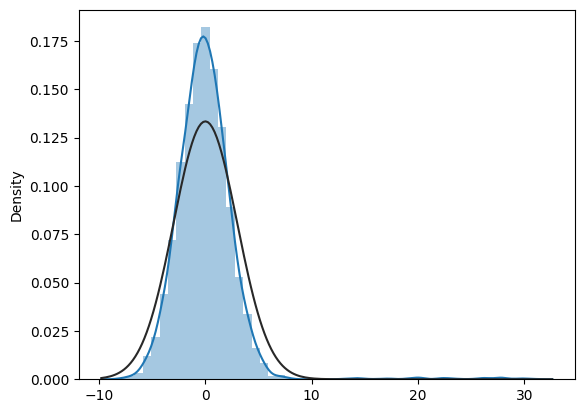

In [200]:
sns.distplot(model2.resid, fit=stats.norm)

Распределение остатков отличается от нормального.

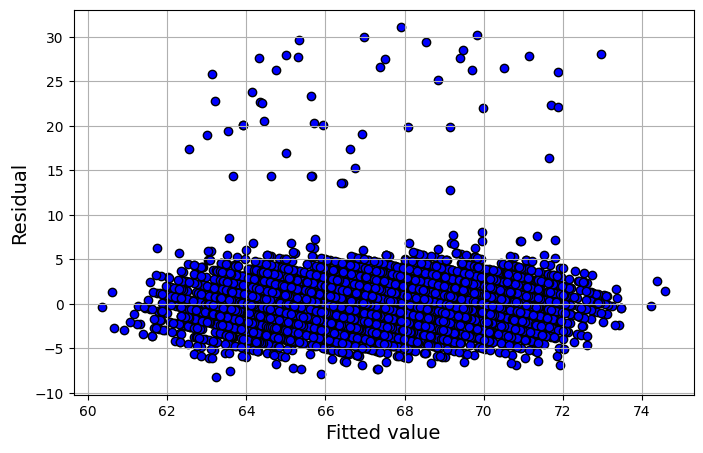

In [201]:
plt.figure(figsize=(8,5))
plt.scatter(x=model2.fittedvalues, y=model2.resid, color='blue', edgecolor='k')
plt.grid(True)
plt.xlabel('Fitted value', fontsize=14)
plt.ylabel('Residual', fontsize=14)
plt.show()

Не наблюдается взаимосвязь между остатками и с предсказанными значениями зависимой переменной. Следовательно проблемы гетероскедастичности нет.

In [202]:
vifs = np.array([vif(model2.model.exog, i) for i in range(model2.model.exog.shape[1])])

In [203]:
vif_df = pd.DataFrame()
vif_df['VIF'] = vifs[1:]
vif_df['Features'] = model2.params.index[1:]
vif_df.sort_values(by=['VIF'])

,VIF,Features
2,1.000680,Tutoring_Sessions
6,1.000779,School_Type_Private
5,1.000957,Learning_Disabilities_Yes
1,1.001248,Previous_Scores
0,1.001596,Attendance
3,1.745389,Motivation_Level_Low
4,1.746620,Motivation_Level_Medium


Нет значений VIF, превышающих 10. Проблема мультиколлинеарности отсутствует.


In [204]:
influence = model2.get_influence()
inf_sum = influence.summary_frame()
inf_sum

,dfb_const,dfb_Attendance,dfb_Previous_Scores,dfb_Tutoring_Sessions,dfb_Motivation_Level_Low,dfb_Motivation_Level_Medium,dfb_Learning_Disabilities_Yes,dfb_School_Type_Private,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
0,0.000034,0.000287,-0.000130,-0.000951,9.068014e-04,-0.000017,-0.000264,-0.000537,4.213005e-07,0.062625,0.000859,0.001836,0.062620,0.001836
1,-0.015211,0.012348,0.010146,-0.003558,-1.040860e-02,0.000015,0.003399,0.005838,7.155624e-05,-0.714447,0.001120,-0.023926,-0.714421,-0.023925
2,-0.015208,0.012943,0.009515,0.003401,8.356609e-05,0.006220,-0.002473,-0.005524,5.448450e-05,0.669134,0.000973,0.020878,0.669106,0.020877
3,-0.005213,0.002960,0.005885,-0.001392,6.130760e-05,0.002787,-0.001144,-0.002393,9.765349e-06,0.295927,0.000891,0.008839,0.295907,0.008838
4,-0.000053,0.000109,-0.000070,0.000131,-3.146155e-08,0.000079,-0.000033,-0.000073,8.055779e-09,0.008800,0.000831,0.000254,0.008800,0.000254
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,0.009581,-0.011435,0.000644,-0.004539,1.672868e-04,0.009085,-0.004122,-0.007763,6.470270e-05,0.977807,0.000541,0.022751,0.977803,0.022751
6603,-0.000477,-0.001991,0.002399,0.006874,1.007088e-04,0.004273,-0.001900,-0.003522,1.662600e-05,0.448841,0.000660,0.011533,0.448814,0.011532
6604,0.001439,-0.003528,0.002847,-0.004966,-4.906021e-03,0.000047,0.001443,0.002891,1.452416e-05,-0.338994,0.001010,-0.010779,-0.338971,-0.010779
6605,0.005422,-0.004478,-0.009489,-0.003561,1.488280e-02,0.016190,0.003114,-0.013207,8.370973e-05,-0.694797,0.001385,-0.025878,-0.694769,-0.025877


In [205]:
inf_sum['dffits'][(inf_sum['dffits']>1) | (inf_sum['dffits']<-1)].sort_values()

,dffits


0 потенциально влияющих наблюдений

In [206]:
inf_sum['standard_resid'][(inf_sum['standard_resid']>3) | (inf_sum['standard_resid']<-3)].sort_values()

,standard_resid
3924,4.292628
1863,4.529679
4254,4.546410
2542,4.795475
1099,4.796412
5989,4.803332
5125,4.805684
2954,5.100332
1607,5.467055
4666,5.682104


In [207]:
len(inf_sum['standard_resid'][(inf_sum['standard_resid']>3) | (inf_sum['standard_resid']<-3)].sort_values())

50

50 выбросов

5. Сформулируйте общие содержательные выводы по результатам регрессионного анализа данных. Какие результаты анализа данных для вас оказались очевидными, а какие неожиданными?

Вывод:

Регулярная посещаемость и дополнительные занятия оказывают большее влияние на экзаменационные результаты, чем предыдущие академические достижения или тип учебного заведения. Психологические факторы, такие как мотивация, также играют важную роль в академической успеваемости.

Очевидным оказалось, что хорошая посещаемость, дополнительные занятия и высокая мотивация положительно влияют на получение хорошей оценки на экзамене. Неожиданостью для меня стало то, что посещаемость является самым важным фактором, чем, напрмер, мотивация. Так же неочевидно, что типы школ не имеют значиния, это опровергает стереотип о превосходстве частного образования.

**Комментарии к заданию и принципам его оценивания:**

 - Все пункты задания должны сопровождаться выполненным фрагментом кода. В этом задании будет проверяться корректность работы кода, то есть будут последовательно запущены ячейки, чтобы убедиться, что код не выдаст ошибку в какой-то момент. Перед отправкой работы на проверку рекомендуется "прогнать" код.
 - Если Вы получили результаты в виде статистических показателей, таблиц или графиков, при этом никак их не прокомментировали и не сформулировали содержательные выводы на их основе, то работа оценивается в 0 баллов, в этом случае анализ данных не проведён.
 - Если Вы полностью выполнили это задание, то получаете за него 8 баллов (отлично). Для получения более высокой оценки нужно выйти за рамки предложенного задания. В случае с текущим заданием это может быть дополнительное самостоятельное изучение инструментов регрессионного анализа и их применение, или развернутое и глубокое исследование имеющихся данных на основе использования пройденных на занятиях методов.
 - В этом задании 5 пунктов. Первый весит 15%, второй - 20%, третий - 40%, четвертый - 20%, пятый - 5%.
 - Задание можно выполнять индивидуально или в группе из 2 человек, критерии оценивания при этом не меняются.
 - Если задание выполняется вдвоем, то в Smart LMS работу загружает только один из студентов.
 - В названии загружаемого в Smart LMS файла нужно указать фамилию(ии) автора(ов) работы.

### Этот файл нужно сохранить как Jupyter Notebook (.ipynb) и загрузить в Smart LMS до 23:55 18 ноября.

- При сдаче работы до 23:55 19 ноября вычитается 1 балл из итоговой оценки.
- При сдаче работы до 23:55 20 ноября вычитаются 2 балла из итоговой оценки.
- После **23:55 20 ноября** работа не принимается.